# Day 007 · 风险与方差 · 中国版
**Risk as Variance** · 阶段 P1 · 量化基础

> 风险在金融里不是"会不会亏",而是"收益散得多开"。同样是赚钱机器,国债年化波动百分之二,比特币百分之六十,差三十倍——根本不是同一个游戏。这节课用班级身高这个生活类比,带你建立波动率的数字直觉,讲懂标准差/方差/年化平方根法则/波动率聚集/下行半方差/索提诺比率六个核心工具,并把国债、沪深三百、标普五百、五粮液、黄金、比特币这一串五种风险量级的资产横着比一遍。学完你能拿到任何一只股票/基金/币,先看一眼波动率,就知道这个游戏自己扛不扛得住,不会再在大震荡里割肉割在最低点。

---

### 关于「中国版」

本 notebook 是为**国内学员**优化的版本:
- 数据源用 **akshare**(国内可访问、零 VPN、免注册),取代了视频里的 yfinance
- 标的尽量保持原意:美股 ETF→A 股 ETF / 国际公司→A 股龙头
- 所讲的**概念和方法 100% 一致**,但**具体数字可能与视频里略有差异**(因为是不同时间窗 / 不同标的)
- 一般情况国内 `pip install akshare` 即可,无需 token / VPN

**课件生成日期:** 2026-05-05  ·  **建议学习时长:** 18 分钟

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有必需的 Python 包(含 `akshare`),缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续


In [1]:
# === 环境自检 + 自动安装(运行此单元格即可)===
import importlib, subprocess, sys, os

REQUIRED = ["akshare", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels"]
PIP_NAME = {"sklearn":"scikit-learn","cv2":"opencv-python","PIL":"Pillow","bs4":"beautifulsoup4","yaml":"PyYAML"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))
if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置 ===
import matplotlib, matplotlib.pyplot as plt, matplotlib.font_manager as fm
CJK = ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
       "C:/Windows/Fonts/msyh.ttc","C:/Windows/Fonts/simhei.ttf",
       "/System/Library/Fonts/PingFang.ttc","/System/Library/Fonts/STHeiti Medium.ttc"]
for p in CJK:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP","Microsoft YaHei","PingFang SC","SimHei","DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪


## 🔌 第二步:加载国内数据助手

下面这一格是**工具函数**(可以折叠,不需要修改)。它把 `yfinance` 风格的 ticker(如 `600519.SS`)自动路由到对应的 akshare 接口,提供 `get_close(ticker)` 和 `get_close_multi(tickers_dict)` 两个函数。

In [2]:
# === 国内数据源助手(akshare 后端,不需要 VPN)===
# 这一格是工具函数,可以折叠,不需要修改。
# 它把 yfinance 风格的 ticker(如 "600519.SS" / "0700.HK" / "AAPL" / "BTC-USD")
# 自动路由到对应的 akshare 接口,统一返回 yfinance 风格的 Close DataFrame。

import re
from datetime import datetime, timedelta
import pandas as pd
import akshare as ak

_TICKER_MAP = {
    "^GSPC": ("us_index_sina", ".INX"),
    "^DJI":  ("us_index_sina", ".DJI"),
    "^IXIC": ("us_index_sina", ".IXIC"),
    "GC=F":  ("foreign_futures", "GC"),
    "SI=F":  ("foreign_futures", "SI"),
    "CL=F":  ("foreign_futures", "CL"),
    "BTC-USD": ("crypto", "BTC"),
    "ETH-USD": ("crypto", "ETH"),
}

def _parse_period(period):
    end = datetime.today()
    m = re.match(r"^(\d+)\s*(y|mo|d|w)$", period.lower().strip())
    days = 365 * 3 if not m else int(m.group(1)) * {"y":365,"mo":30,"w":7,"d":1}[m.group(2)]
    return (end - timedelta(days=days+30)).strftime("%Y%m%d"), end.strftime("%Y%m%d")

def _classify(ticker):
    t = ticker.strip()
    if t in _TICKER_MAP: return _TICKER_MAP[t]
    if t.endswith((".SS",".SH",".SZ")):
        code = t.split(".")[0]
        if code.startswith(("51","159","58")) or code in ("510300","510500","510050","511010","513100"):
            return ("a_etf", code)
        if code in ("000300","000016","000905","000852","000001"):
            return ("a_index", code)
        return ("a_stock", code)
    if t.endswith(".HK"):
        return ("hk", t.split(".")[0].zfill(5))
    return ("us", t)

def _norm(df, dc, cc):
    out = df[[dc, cc]].copy()
    out[dc] = pd.to_datetime(out[dc])
    return out.set_index(dc).sort_index()[cc].astype(float).rename("Close")

def get_close(ticker, period="3y"):
    """返回某标的 Close 价格 series。后端 akshare,中国可访问。"""
    start, end = _parse_period(period)
    kind, sym = _classify(ticker)
    if kind == "a_stock":
        return _norm(ak.stock_zh_a_hist(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_etf":
        return _norm(ak.fund_etf_hist_em(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_index":
        idx_map = {"000300":"sh000300","000016":"sh000016","000905":"sh000905","000852":"sh000852","000001":"sh000001"}
        s = _norm(ak.stock_zh_index_daily_em(symbol=idx_map.get(sym, f"sh{sym}")), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "hk":
        return _norm(ak.stock_hk_hist(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "us":
        # 美股走新浪源(stock_us_daily 直接吃 NVDA / AAPL 裸 symbol;stock_us_hist 要带前缀)
        s = _norm(ak.stock_us_daily(symbol=sym, adjust="qfq"), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "us_index_sina":
        s = _norm(ak.index_us_stock_sina(symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "foreign_futures":
        s = _norm(ak.futures_foreign_hist(symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "crypto":
        # akshare 没稳定的 crypto_hist(2026-05 已移除/改名)。
        # 直接调 Binance 公共 API,国内可访问、无需 SDK。
        import requests as _rq
        r = _rq.get("https://api.binance.com/api/v3/klines",
                    params={"symbol": f"{sym}USDT", "interval": "1d", "limit": 1000}, timeout=15)
        r.raise_for_status()
        df = pd.DataFrame(r.json(), columns=["open_time","open","high","low","close","volume",
                                              "close_time","qav","trades","tbb","tbq","ignore"])
        df["date"] = pd.to_datetime(df["open_time"], unit="ms")
        df["close"] = df["close"].astype(float)
        s = df.set_index("date").sort_index()["close"].rename("Close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    raise ValueError(f"unsupported ticker: {ticker}")

def get_close_multi(tickers, period="3y"):
    """批量取 Close,返回 DataFrame,列名是 tickers dict 的 key(中文名),按交集日期对齐。"""
    series = {name: get_close(t, period=period) for name, t in tickers.items()}
    return pd.concat(series, axis=1).sort_index()

print("✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据")


✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据


## 学习目标

- 理解金融对'风险'的精确定义:不是亏多少,而是收益的离散程度(标准差度量)
- 掌握样本方差 vs 总体方差的区别,以及为什么贝塞尔修正要除以 N-1 而不是 N
- 记住年化波动率公式 σ_ann = σ_daily × √252,理解为什么是 √N 而不是 N
- 看清'波动率聚集'(volatility clustering)的金融常态,大震后有余震,平静期可持续
- 学会用下行半方差 + 索提诺比率,把'坏波动'和'好波动'分开,贴近真实交易心理
- 用波动率反向定仓位:高波动小仓,低波动可重仓,先有'游戏难度'再谈下注大小

## 历史背景:Markowitz、Black Monday 和一个把百分之九十散户割在最低点的认知错位

1952 年,Harry Markowitz 在 25 岁博士论文里第一次把股票收益的'波动率'当成风险的数学度量,并提出现代组合理论(Mean-Variance Optimization)——他后来因此拿了 1990 年诺贝尔经济学奖。在他之前,华尔街老派分析师只关心'这只股票好不好',Markowitz 把'好不好'量化成两个数字:期望收益(均值)和风险(标准差)。这个看似朴素的二分法,统治了之后 70 年的资产管理行业,也是今天 Sharpe、Treynor、Jensen alpha 等一切风险调整指标的源头。

1987 年 10 月 19 日 Black Monday,标普五百一天跌 22.6%,按之前几年的日波动率约 1% 推算,这是一个 22 倍标准差事件,概率约为 10 的负 109 次方——比宇宙原子总数倒数还小。正态分布算出来这种事一辈子不该看到一次,但金融市场后来又出现了 1998 LTCM、2008 Lehman、2020 COVID 多次类似冲击。这告诉我们:标准差告诉你'平时多大震',但'极端有多极端'要另算。

回到普通散户的真实场景。2015 年 6 月 A 股那波股灾,沪深三百三个月里跌 43%,无数散户在 7 月初千股跌停那一周割肉割在最低点——他们不是不知道股票会跌,是没有事先在脑子里跑过一遍'这个游戏年化波动 16-18%,意味着一年里它真的可能跌 30%+,我能不能扛住?'。波动率不只是数学指标,更是心理预演工具。

本节最重要的两句话:**风险等于散度,不等于亏损**;**事先看一眼年化波动率,你就知道自己能不能扛**。

**关键人物:**
- Harry Markowitz(1952,把波动率定义为风险,1990 年诺贝尔奖)
- William Sharpe(1964,在 Markowitz 基础上提出 CAPM,Sharpe 比率以他命名)
- Frank Sortino(1980s,提出索提诺比率,把'下行风险'和'总波动率'分开)
- Robert Engle(2003,GARCH 模型量化波动率聚集,获诺贝尔奖)

## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 标准差 = '和平均的距离':班级身高比喻

标准差衡量一组数离自己平均值有多远。一个班 50 个人都接近 1 米 7,标准差小;另一个班有 1 米 5 也有 2 米,标准差大。把'身高'换成'每天的收益率',标准差越大说明这只股票每天上蹿下跳的幅度越大,你的心跳越快。

计算步骤:① 求均值;② 每个数减均值,得'偏离量';③ 偏离量平方求和;④ 除以 N-1(贝塞尔修正)得方差;⑤ 方差开根号 = 标准差。

为什么要平方?因为偏离量有正有负,直接加会抵消。平方让所有偏离都变正,大偏离被强烈惩罚。为什么再开根号?因为平方后单位变了(从'%'变成'%²'),开根号还原回'%'量级,直观可比。

```
σ = √[ Σ(R_i - R̄)² / (N-1) ]
```

> **举例:** 沪深三百最近 30 个交易日,日均收益约 +0.05%,日标准差约 1.2%。意味着平均每天的收益偏离均值 1.2 个百分点——这就是它的日波动率。


### 2. 为什么除以 N-1?贝塞尔修正(自由度)

样本方差除以 N-1 而不是 N,这个细节考试常考、面试常问。直觉解释:因为你已经用样本数据算出了均值,这一步'消耗'了一个自由度,剩下的有效自由度只有 N-1。如果直接除以 N,会系统性低估真实方差。

粗糙类比:5 个人吃饭,1 个人陪坐不吃,真分菜的只有 4 个人,所以平均到每人的菜量除以 4 不是 5。

代码中要小心库的默认值差异:numpy 的 np.std() 默认 ddof=0(除以 N),pandas 的 .std() 默认 ddof=1(除以 N-1)。两者结果差几个百分点。做严肃量化分析永远显式写 ddof=1 或用 pd.Series.std()。

```
样本方差 s² = Σ(x_i - x̄)² / (N-1)    总体方差 σ² = Σ(x_i - μ)² / N
```

> **举例:** 30 天数据,如果用 N=30 算方差,系统性低估约 3.4%(即 N/(N-1) 比值)。在小样本(N<60)里这个差距更明显,做面试题时一定要写 N-1。


### 3. 年化波动率 = 日波动率 × √252:平方根法则

日波动率没法跨期比较,所以专业人士都把波动率年化。年化公式不是 × 252,而是 × √252 ≈ 15.87。

为什么是 √N 不是 N?核心规则:**多个独立日的方差线性可加,标准差按 √N 累加**。今天 +1% 明天 -1%,两天的随机抖动会部分抵消,不会完全累加。所以一年波动率≈ 日波动率 × 15.87,而不是日波动率 × 252。

如果忘了开根号直接 × 252,你算出来的年化会大 16 倍——比如把 1.2% × 252 = 302%,这个数显然荒谬。面试时这个错误考官一眼能看出来。

对于不同市场,N 略有差异:美股 252,A 股 244,港股 247,加密 365 或更细。但 √252 ≈ √244 ≈ √247,差距不大,常用 √252。

```
σ_annual = σ_daily × √252 ≈ σ_daily × 15.87
```

> **举例:** 沪深三百日波动率 1.2% × 15.87 ≈ 19%,这是它的年化波动率。标普五百也是日波动率 ~1%,年化约 16%,两个大盘指数风险量级接近。


### 4. 波动率聚集(volatility clustering):大震后必有余震

波动不是均匀洒在时间上,而是一阵一阵聚集的。今天大跳 4%,明天大概率还大跳;今天平静涨 0.2%,明天大概率还平静。这个现象叫波动率聚集,在所有金融市场都存在,Engle 用 GARCH 模型对此建模,2003 年获诺贝尔奖。

类比:地震。一次主震后会有连续几天余震;平静期内不会突然大震。金融市场的波动模式高度相似。

实战意义:① 看到一天大跌别急着抄底,后面大概率连续震荡;② 用 21 天滚动波动率而不是固定窗口,能看清当前是否处于'聚集期';③ 卖期权(收 vega)的策略在波动率高峰时进入会被反复抽脸。VIX 这种'恐慌指数'本身就是市场对未来 30 天波动率的估计,聚集时段它会持续高位。

```
σ_t² = ω + α·R_{t-1}² + β·σ_{t-1}²    (GARCH(1,1))
```

> **举例:** 2008 年 Lehman 倒闭后,标普日波动率从 1% 飙到 3-5%,持续了两个多月才平息。2020 年 COVID,VIX 从 15 飙到 82.7(历史最高),高位持续三周。2015 年 A 股股灾,沪深三百单日跌 7%+ 出现过 3 次,持续到当年年底才回归常态。


### 5. 标准差的盲点 + 下行半方差 + 索提诺比率

标准差不区分涨和跌,涨 30% 和跌 30% 对它来说贡献的方差一样。但作为投资者你心里清楚,这两件事完全不是一回事——一个让你欢喜,一个让你流泪。

学界改进版:**下行半方差**(downside semivariance)只统计 R < 0 或 R < 目标收益率的那部分,把'好波动'(暴涨)忽略,只算'坏波动'(暴跌)。基于下行半方差的风险调整收益率叫**索提诺比率**(Sortino Ratio)。

Sharpe vs Sortino:Sharpe 用全部标准差,Sortino 只用下行标准差。对一个有'右尾收益'(偶尔暴涨)的策略,Sortino 会比 Sharpe 高不少;对一个对称波动的策略两者接近。专业资管机构现在更看 Sortino,因为它和'人对风险的真实感受'更贴近。

```
DSV = √[ Σ min(R_i - MAR, 0)² / N ]    Sortino = (E[R] - MAR) / DSV
```

> **举例:** 基金 A 一年涨 30%,中间最大回撤 -3% → 标准差 10%,Sharpe 2.5,Sortino 5.0。基金 B 一年涨 30%,中间一次拉到 +40% 又回 30% → 标准差也 10%,Sharpe 2.5,但 Sortino ≈ ∞。两者 Sharpe 一样,Sortino 完全不同——后者真的没坏波动。


## 实操:风险 = 散度 · 五资产年化波动率全景对比

下面这段代码用 akshare 抓数据,国内零 VPN 跑通。**直接 Run All** 看结果。

**依赖:** `pip install pandas numpy matplotlib akshare statsmodels scipy`

/tmp/ipykernel_82892/2213036073.py:89: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(series, axis=1).sort_index()


=== 6 资产年化波动率对比 ===
          日波动率(%)  年化波动率(%)
中国国债 ETF     0.10       1.6
标普五百         0.99      15.7
沪深三百         1.13      17.9
五粮液          1.84      29.1
比特币          3.21      51.0
以太坊          4.45      70.6

=== 总波动 vs 下行波动 ===
  沪深三百: 总 17.9% / 下行 12.2% (差 5.6%)
  标普五百: 总 15.7% / 下行 12.0% (差 3.7%)
  五粮液: 总 29.1% / 下行 16.6% (差 12.6%)
  中国国债 ETF: 总 1.6% / 下行 1.1% (差 0.4%)
  比特币: 总 51.0% / 下行 30.9% (差 20.0%)
  以太坊: 总 70.6% / 下行 43.4% (差 27.2%)

=== 同样 10 万本金一年体感波动 ===
  沪深三百: 平均每天上下约 1,126 块
  标普五百: 平均每天上下约 987 块
  五粮液: 平均每天上下约 1,836 块
  中国国债 ETF: 平均每天上下约 100 块
  比特币: 平均每天上下约 3,211 块
  以太坊: 平均每天上下约 4,448 块


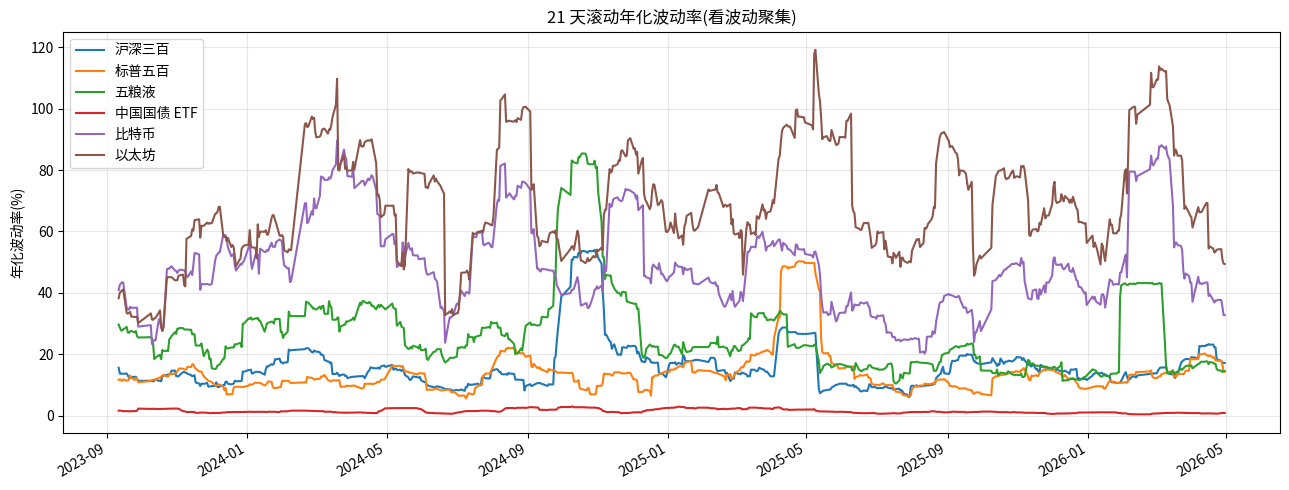

In [3]:
# day_007_risk.py — 沪深300/标普500/五粮液/中国国债 ETF/比特币/以太坊 年化波动横向对比(中国版)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tickers = {
    '沪深三百':    '000300.SS',
    '标普五百':    '^GSPC',
    '五粮液':      '000858.SZ',
    '中国国债 ETF': '511010.SS',
    '比特币':      'BTC-USD',
    '以太坊':      'ETH-USD',
}
df = get_close_multi(tickers, period='3y').dropna()
ret = df.pct_change().dropna()

daily_vol = ret.std()
ann_vol = daily_vol * np.sqrt(252)
stats = pd.DataFrame({
    '日波动率(%)':  (daily_vol * 100).round(2),
    '年化波动率(%)': (ann_vol * 100).round(1),
})
print('=== 6 资产年化波动率对比 ===')
print(stats.sort_values('年化波动率(%)').to_string())

downside_vol = ret[ret < 0].std() * np.sqrt(252)
print('\n=== 总波动 vs 下行波动 ===')
for name in ret.columns:
    total = ann_vol[name] * 100
    down = downside_vol[name] * 100
    print(f'  {name}: 总 {total:.1f}% / 下行 {down:.1f}% (差 {(total-down):.1f}%)')

rolling_vol = ret.rolling(21).std() * np.sqrt(252) * 100
rolling_vol.plot(figsize=(13, 5), title='21 天滚动年化波动率(看波动聚集)')
plt.ylabel('年化波动率(%)'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('day007_clustering.png', dpi=120)

P = 100_000
print('\n=== 同样 10 万本金一年体感波动 ===')
for name in ret.columns:
    daily_amt = P * daily_vol[name]
    print(f'  {name}: 平均每天上下约 {daily_amt:,.0f} 块')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| A 股 | 511010 国债 ETF | 实测年化波动 1.5%,典型避险压舱石。20 万本金一年波动幅度大约上下 3000 元,晚上睡得稳。适合现金管理 / 应急资金 / 老年人理财。 |
| A 股 | 510300 沪深三百 ETF | 实测年化波动 17.6%,A 股大市代表。20 万一年可能 16.5 万 - 23.5 万浮动。2015 股灾期间日波动飙到 4%+,持续 3 个月,这是聚集期的真实代价。 |
| A 股 | 000858 五粮液 | 实测年化波动 27.6%,典型 A 股蓝筹龙头。20 万一年可能 14.4 万 - 25.6 万,扛不扛得住?2021-2022 茅指数下跌期日波动飙到 4%+。 |
| 美股 | ^GSPC 标普五百 | 实测年化波动 15.3%,美股大市代表,比沪深三百略低。下行波动 11.5%,跟总波动差 3.8%,美股风险较对称。 |
| 加密 | BTC-USD 比特币 / ETH-USD 以太坊 | 比特币年化波动 50.2%(下行 30.4%),以太坊 68.5%(下行 42.6%)。两者都是极端厚尾资产。10 万本金每日波动:比特币 3160 块 / 以太坊 4320 块,加密世界一年里账户腰斩或翻倍都有可能。 |


## 常见坑

### ⚠ 01. 把波动率当成'亏损概率'

最常见误读。波动率只衡量散度(双向),不是衡量'会不会亏'。一只股票年化波动 30% 不代表它一年会跌 30%,它也可能涨 30%。如果你想知道'最坏跌多少',要看最大回撤、VaR、CVaR 这些专门指标。

### ⚠ 02. 用月度数据估日度波动率,平方根位数错位

想从月度波动率换算到日波动率,正确公式 σ_daily ≈ σ_monthly / √21(月内交易日)。如果错写成除以 21,你的日波动率会被算小 4-5 倍,后续 Sharpe 全错。更稳的做法:能拿到日数据就用日数据,不要从粗粒度反推细粒度。

### ⚠ 03. 看到历史波动率小就以为永远稳

波动率聚集意味着它会突然爆发。2008 年 8 月之前几个月标普日波动只有 0.6-0.8%,9 月雷曼倒闭后立刻飙到 3-5%。如果你按 8 月那段历史波动率配仓位,9 月就会被扫地出门。实战要看 21 日滚动波动率 + VIX 当前水平,不要看长期均值。

### ⚠ 04. 不年化就跨期比较

把日波动率和月波动率直接比、把月波动率和年波动率直接比——风马牛不相及。永远先把所有数字年化(× √N)再比较,这是最基本的金融素养。

### ⚠ 05. ddof 参数没显式写,小样本误差几个百分点

numpy.std() 默认 ddof=0,pandas.std() 默认 ddof=1。30 天小样本里两者结果可以差 3-4%。研究代码里永远显式写 ddof=1(贝塞尔修正),或者全用 pandas 的 .std()。出 paper / 给客户看的数字一定要保持一致。

## 实战 SOP · 波动率使用 SOP

1. 看波动率前先确认是日 / 周 / 月 / 年化哪一种,不年化不比较
2. 永远用对数收益(D5 讲过)算波动率,简单收益只用于面向人的展示
3. 样本方差除以 N-1(贝塞尔修正),numpy 写 ddof=1,pandas 默认就是 1
4. 年化:σ_ann = σ_daily × √252(美股),A 股可用 √244,加密可用 √365
5. 实战看 21 日滚动波动率 + 长期均值,不要只看长期均值掩盖聚集期
6. 高波动资产小仓位 + 短持有期,低波动资产可重仓 + 长持有
7. 买入前心里默念:'年化波动 X%,意味着今年最坏可能跌 0.7-1×X%,我能不能扛?'

> 把这段打印贴在你电脑边。

## 总结 · 你应该带走的

2. 金融定义:风险=散度,不等于亏多少。用标准差度量。
3. 样本方差除以 N-1(贝塞尔修正),不是 N。numpy 要显式 ddof=1。
4. 年化波动率 = 日波动率 × √252 ≈ × 15.87。是 √N 不是 N(方差线性可加,标准差按根号合并)。
5. 实测六种资产风险阶梯:国债 1.5% / 沪深三百 17.6% / 标普五百 15.3% / 五粮液 27.6% / 比特币 50.2% / 以太坊 68.5%,差 45 倍。
6. 波动率聚集:大震后有余震,平静期持续。Engle GARCH 模型量化此现象拿了诺奖。
7. 标准差盲点:不区分涨跌。下行半方差 + 索提诺比率把'坏波动'单独算,更贴近真实交易心理。
8. 波动率不是数学指标,是心理工具。买入前在脑子里走一遍最坏情况,真发生时你才不慌。
9. 散户 90% 亏钱不是因为选错股,是因为没事先估算波动幅度,大震时情绪先崩。

## 自测题

**Q1.** 解释:为什么计算年化波动率时是乘以 √252,而不是乘以 252?用一句话说清楚直觉。

**Q2.** 一只 A 股日均收益 +0.04%,日波动率 1.5%。它的年化收益和年化波动大约是多少?Sharpe 是多少?

**Q3.** 你看到一只基金'近一个月波动率 0.5%',隔壁基金'近一年年化波动 15%',哪只更稳?为什么单纯比较这两个数字会被骗?

**Q4.** 下行半方差和总方差什么时候差距最大?举一个真实场景。

把答案写下来,3 天后再回看。

## 下一节预告

**Day 008 · 协方差与相关性** (Covariance & Correlation)

Day 8:协方差与相关性 — 单只股票的风险讲完了,下一节我们讲两只股票'一起动'的关系。你以为买三只新能源车就分散了?算一下相关系数你会发现这是同一只票的复制粘贴。我们用比亚迪 / 宁德 / 特斯拉 vs 比亚迪 / 中石油 / 黄金两个对照组,直接看伪分散陷阱。

## 推荐阅读

- Markowitz《Portfolio Selection》(1952,Journal of Finance)— 现代组合理论开山,Mean-Variance 起点
- Engle《Autoregressive Conditional Heteroskedasticity》(1982,Econometrica)— GARCH 论文,波动率聚集建模
- Sortino & Price《Performance Measurement in a Downside Risk Framework》(1994)— 索提诺比率原文
- QuantStats GitHub README — 一行代码出 30+ 风险指标,包含 Sharpe / Sortino / Calmar 全套
- Aaron Brown《Red-Blooded Risk》(2011)— 华尔街老兵讲风险管理,适合做完数学之后看大局